# 04 - Valores atípicos y consistencia cuantitativa

**Objetivo.** Detectar valores imposibles, inconsistentes o extremos en variables cuantitativas relevantes. En esta etapa no se eliminan automáticamente outliers plausibles: se crean flags para sostener decisiones posteriores.

En real estate, un valor extremo puede ser válido. Por eso se distinguen valores imposibles de extremos plausibles.

In [1]:
from pathlib import Path
import json
import re
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 180)


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontro la raiz del repo. Ejecutar dentro del proyecto.')

REPO_ROOT = find_repo_root()
RAW_DIR = REPO_ROOT / 'data' / 'raw'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
REPORTS_DIR = PROCESSED_DIR / 'reports'
EXTERNAL_DIR = REPO_ROOT / 'Fuentes_de_enriquecimiento'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print('REPO_ROOT:', REPO_ROOT)
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

REPO_ROOT: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026
RAW_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\raw
PROCESSED_DIR: C:\Users\arira\OneDrive\Documents\GitHub\TP_analitica_descriptiva_grupo1_2q2026\data\processed


## Carga de datasets con flags de nulos

Si todavía no existen, se cargan los datasets preprocesados del notebook 02.

In [ ]:
base_sources = {
    'df_preprocesado_meli_alq': PROCESSED_DIR / 'df_preprocesado_meli_alq_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_alq_temp': PROCESSED_DIR / 'df_preprocesado_meli_alq_temp_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_vtas': PROCESSED_DIR / 'df_preprocesado_meli_vtas_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_vtas': PROCESSED_DIR / 'df_preprocesado_argenprop_vtas_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_alq': PROCESSED_DIR / 'df_preprocesado_argenprop_alq_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_vtas': PROCESSED_DIR / 'df_preprocesado_zonaprop_vtas_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_alq': PROCESSED_DIR / 'df_preprocesado_zonaprop_alq_post_ajustes_con_flags_nulos_v1.csv',
    'df_preprocesado_airbnb_temp': PROCESSED_DIR / 'df_preprocesado_airbnb_temp_post_ajustes_con_flags_nulos_v1.csv',
}

fallback_sources = {
    'df_preprocesado_meli_alq': PROCESSED_DIR / 'df_preprocesado_meli_alq_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_alq_temp': PROCESSED_DIR / 'df_preprocesado_meli_alq_temp_con_flags_nulos_v1.csv',
    'df_preprocesado_meli_vtas': PROCESSED_DIR / 'df_preprocesado_meli_vtas_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_vtas': PROCESSED_DIR / 'df_preprocesado_argenprop_vtas_con_flags_nulos_v1.csv',
    'df_preprocesado_argenprop_alq': PROCESSED_DIR / 'df_preprocesado_argenprop_alq_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_vtas': PROCESSED_DIR / 'df_preprocesado_zonaprop_vtas_con_flags_nulos_v1.csv',
    'df_preprocesado_zonaprop_alq': PROCESSED_DIR / 'df_preprocesado_zonaprop_alq_con_flags_nulos_v1.csv',
    'df_preprocesado_airbnb_temp': PROCESSED_DIR / 'df_preprocesado_airbnb_temp_con_flags_nulos_v1.csv',
}

preprocesados_outliers = {}

for name, path in base_sources.items():
    source = path if path.exists() else fallback_sources[name]

    if not source.exists():
        raise FileNotFoundError(f'Falta {source}. Ejecutar notebooks anteriores.')

    preprocesados_outliers[name] = pd.read_csv(source, low_memory=False)
    print(name, preprocesados_outliers[name].shape, 'desde', source.name)

df_preprocesado_meli_alq (11479, 79) desde df_preprocesado_meli_alq_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_meli_alq_temp (6190, 81) desde df_preprocesado_meli_alq_temp_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_meli_vtas (44013, 82) desde df_preprocesado_meli_vtas_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_argenprop_vtas (82, 60) desde df_preprocesado_argenprop_vtas_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_argenprop_alq (80, 59) desde df_preprocesado_argenprop_alq_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_zonaprop_vtas (485, 62) desde df_preprocesado_zonaprop_vtas_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_zonaprop_alq (495, 56) desde df_preprocesado_zonaprop_alq_post_ajustes_con_flags_nulos_v1.csv
df_preprocesado_airbnb_temp (9596, 85) desde df_preprocesado_airbnb_temp_post_ajustes_con_flags_nulos_v1.csv


## Funciones de detección de outliers

In [3]:
VARIABLES_OUTLIERS = ['precio', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref', 'altura', 'latitud', 'longitud', 'rating', 'reviews']

CABA_LAT_MIN, CABA_LAT_MAX = -34.75, -34.50
CABA_LON_MIN, CABA_LON_MAX = -58.55, -58.30


def add_outlier_flags(df, dataset_name, p_low=0.01, p_high=0.99):
    out = df.copy()
    rows = []
    group_cols = [c for c in ['fuente_norm', 'tipo_operacion_norm', 'moneda_norm'] if c in out.columns]

    for col in VARIABLES_OUTLIERS:
        if col not in out.columns or not pd.api.types.is_numeric_dtype(out[col]):
            continue
        s = out[col]

        invalid_flag = f'{col}_valor_invalido_flag'
        if col in ['precio', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref']:
            out[invalid_flag] = (s.notna() & (s <= 0)).astype('int8')
        elif col == 'rating':
            out[invalid_flag] = (s.notna() & ((s < 0) | (s > 5))).astype('int8')
        elif col == 'latitud':
            out[invalid_flag] = (s.notna() & ((s < CABA_LAT_MIN) | (s > CABA_LAT_MAX))).astype('int8')
        elif col == 'longitud':
            out[invalid_flag] = (s.notna() & ((s < CABA_LON_MIN) | (s > CABA_LON_MAX))).astype('int8')
        else:
            out[invalid_flag] = 0

        valid = out[out[invalid_flag].eq(0) & out[col].notna()].copy()
        outlier_flag = f'{col}_outlier_p01_p99_flag'
        out[outlier_flag] = 0

        if valid.empty or valid[col].nunique(dropna=True) <= 1:
            continue

        if group_cols:
            qs = valid.groupby(group_cols)[col].quantile([p_low, p_high]).unstack()
            qs.columns = ['p01', 'p99']
            valid = valid.join(qs, on=group_cols)
            mask_outlier = (valid[col] < valid['p01']) | (valid[col] > valid['p99'])
            out.loc[valid.index, outlier_flag] = mask_outlier.astype('int8')
        else:
            q_low, q_high = valid[col].quantile([p_low, p_high])
            mask_outlier = (valid[col] < q_low) | (valid[col] > q_high)
            out.loc[valid.index, outlier_flag] = mask_outlier.astype('int8')

        rows.append({
            'dataset': dataset_name,
            'variable': col,
            'n_no_nulos': int(s.notna().sum()),
            'n_invalidos': int(out[invalid_flag].sum()),
            'n_outliers_p01_p99': int(out[outlier_flag].sum()),
            'pct_invalidos': round(out[invalid_flag].mean() * 100, 2),
            'pct_outliers_p01_p99': round(out[outlier_flag].mean() * 100, 2),
        })

    return out, pd.DataFrame(rows)

## Valores Extremos con IQR

Se buscan valores extremos con IQR, pero comparando propiedades dentro de grupos similares, para complementar el P01–P99.

In [4]:
# ============================================================
# OUTLIERS - MÉTODO IQR
# TODAS LAS BASES
# ============================================================

VARIABLES_IQR = [
    'precio',
    'precio_m2_ref',
    'precio_noche_estimado',
    'precio_mensual_estimado',
    'superficie_ref_m2',
    'ambientes_ref',
    'dormitorios_ref',
    'banios_ref',
    'altura'
]


def add_iqr_flags_todas_las_bases(df):
    """
    Detecta outliers mediante el criterio IQR.

    El cálculo se realiza dentro de cada dataset_preprocesado,
    evitando comparar distribuciones diferentes entre sí.
    """

    df = df.copy()

    reporte = []

    for var in VARIABLES_IQR:

        # Si la variable no existe, continuar
        if var not in df.columns:
            continue

        flag_col = f'{var}_outlier_iqr_flag'

        # Inicializar flag
        df[flag_col] = False

        # Convertir a numérico
        valores = pd.to_numeric(
            df[var],
            errors='coerce'
        )

        # Valores válidos
        mask_validos = valores.notna()

        # ----------------------------------------------------
        # Calcular Q1 y Q3 por dataset
        # ----------------------------------------------------

        q1 = df.groupby(
            'dataset_preprocesado',
            dropna=False
        )[var].transform(
            lambda x: x.quantile(0.25)
        )

        q3 = df.groupby(
            'dataset_preprocesado',
            dropna=False
        )[var].transform(
            lambda x: x.quantile(0.75)
        )

        # ----------------------------------------------------
        # Calcular IQR
        # ----------------------------------------------------

        iqr = q3 - q1

        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr

        # ----------------------------------------------------
        # Detectar outliers
        # ----------------------------------------------------

        df.loc[
            mask_validos &
            (
                (valores < limite_inferior) |
                (valores > limite_superior)
            ),
            flag_col
        ] = True

        # ----------------------------------------------------
        # Reporte por dataset
        # ----------------------------------------------------

        for dataset, grupo in df.groupby(
            'dataset_preprocesado',
            dropna=False
        ):

            mask_dataset = (
                df['dataset_preprocesado']
                == dataset
            )

            n_validos = int(
                (
                    mask_validos &
                    mask_dataset
                ).sum()
            )

            n_outliers = int(
                (
                    df.loc[
                        mask_dataset,
                        flag_col
                    ]
                ).sum()
            )

            reporte.append({
                'dataset': dataset,
                'variable': var,
                'n_validos': n_validos,
                'n_outliers_iqr': n_outliers,
                'pct_outliers_iqr': (
                    round(
                        100 * n_outliers / n_validos,
                        2
                    )
                    if n_validos > 0
                    else np.nan
                )
            })

    return df, pd.DataFrame(reporte)

## Aplicación por dataset

In [5]:
preprocesados_con_outliers = {}
reportes_outliers = []
for name, df in preprocesados_outliers.items():
    df_out, reporte = add_outlier_flags(df, name)
    preprocesados_con_outliers[name] = df_out
    if not reporte.empty:
        reportes_outliers.append(reporte)
    print(name, df_out.shape, 'flags outliers:', sum(c.endswith('_flag') for c in df_out.columns))

reporte_outliers = pd.concat(reportes_outliers, ignore_index=True) if reportes_outliers else pd.DataFrame()
display(reporte_outliers)
reporte_outliers.to_csv(REPORTS_DIR / 'reporte_outliers_v1.csv', index=False)

df_preprocesado_meli_alq (11479, 93) flags outliers: 14
df_preprocesado_meli_alq_temp (6190, 95) flags outliers: 14
df_preprocesado_meli_vtas (44013, 96) flags outliers: 14
df_preprocesado_argenprop_vtas (82, 74) flags outliers: 14
df_preprocesado_argenprop_alq (80, 73) flags outliers: 14
df_preprocesado_zonaprop_vtas (485, 74) flags outliers: 12
df_preprocesado_zonaprop_alq (495, 68) flags outliers: 12
df_preprocesado_airbnb_temp (9596, 105) flags outliers: 20


,dataset,variable,n_no_nulos,n_invalidos,n_outliers_p01_p99,pct_invalidos,pct_outliers_p01_p99
0,df_preprocesado_meli_alq,precio,11479,0,206,0.00,1.79
1,df_preprocesado_meli_alq,precio_m2_ref,11429,0,230,0.00,2.00
2,df_preprocesado_meli_alq,superficie_ref_m2,11429,0,220,0.00,1.92
3,df_preprocesado_meli_alq,ambientes_ref,11183,0,95,0.00,0.83
4,df_preprocesado_meli_alq,dormitorios_ref,43,0,0,0.00,0.00
5,df_preprocesado_meli_alq,banios_ref,11263,0,26,0.00,0.23
6,df_preprocesado_meli_alq,altura,9836,0,188,0.00,1.64
7,df_preprocesado_meli_alq_temp,precio,6190,0,124,0.00,2.00
8,df_preprocesado_meli_alq_temp,precio_m2_ref,6165,0,117,0.00,1.89
9,df_preprocesado_meli_alq_temp,superficie_ref_m2,6165,0,114,0.00,1.84


## Aplicar a las bases outliers por IQR

In [6]:
(
    df_publicaciones_consolidadas_outliers,
    reporte_iqr_todas
) = add_iqr_flags_todas_las_bases(
    df_publicaciones_consolidadas_outliers
)

display(reporte_iqr_todas)

NameError: name 'df_publicaciones_consolidadas_outliers' is not defined

## Resumen IQR por Base

In [ ]:
resumen_iqr = (
    reporte_iqr_todas
    .pivot_table(
        index='dataset',
        columns='variable',
        values='pct_outliers_iqr'
    )
)

display(resumen_iqr)

variable,altura,ambientes_ref,banios_ref,dormitorios_ref,precio,precio_m2_ref,precio_mensual_estimado,precio_noche_estimado,superficie_ref_m2
dataset,,,,,,,,,
df_preprocesado_airbnb_temp,NaN,32.56,9.58,32.56,8.83,NaN,8.83,8.83,NaN
df_preprocesado_argenprop_alq,1.28,8.70,23.68,1.52,7.50,18.31,NaN,NaN,12.68
df_preprocesado_argenprop_vtas,0.00,1.61,2.94,0.00,8.54,2.56,NaN,NaN,6.41
df_preprocesado_meli_alq,1.94,0.24,19.79,0.00,1.44,0.28,NaN,NaN,9.32
df_preprocesado_meli_alq_temp,1.25,0.25,13.62,0.00,16.67,24.43,NaN,NaN,6.03
df_preprocesado_meli_vtas,1.71,4.56,1.79,2.96,9.03,4.94,NaN,NaN,6.88
df_preprocesado_zonaprop_alq,NaN,0.41,3.07,3.10,1.62,0.00,NaN,NaN,8.96
df_preprocesado_zonaprop_vtas,NaN,0.83,6.65,0.26,11.74,7.35,NaN,NaN,4.13


## Celdas de decisión: tratamiento de valores inválidos y outliers

La estrategia por defecto es **marcar** valores inválidos y extremos. No se eliminan outliers plausibles porque en el mercado inmobiliario pueden representar propiedades reales. Si se decide limpiar de forma activa, se recomienda transformar a nulo solo valores imposibles y documentar el impacto.

In [ ]:
# Parametros conservadores.
NULIFICAR_VALORES_INVALIDOS = False
ELIMINAR_OUTLIERS_P01_P99 = False

resumen_decisiones_outliers = []
for name, df in preprocesados_con_outliers.items():
    filas_antes = len(df)
    invalid_flags = [c for c in df.columns if c.endswith('_valor_invalido_flag')]
    outlier_flags = [c for c in df.columns if c.endswith('_outlier_p01_p99_flag')]

    filas_con_invalido = int(df[invalid_flags].any(axis=1).sum()) if invalid_flags else 0
    filas_con_outlier = int(df[outlier_flags].any(axis=1).sum()) if outlier_flags else 0

    if NULIFICAR_VALORES_INVALIDOS:
        for flag_col in invalid_flags:
            base_col = flag_col.replace('_valor_invalido_flag', '')
            if base_col in df.columns:
                df.loc[df[flag_col].eq(1), base_col] = np.nan

    if ELIMINAR_OUTLIERS_P01_P99 and outlier_flags:
        df = df.loc[~df[outlier_flags].any(axis=1)].copy()

    preprocesados_con_outliers[name] = df
    resumen_decisiones_outliers.append({
        'dataset': name,
        'filas_antes': filas_antes,
        'filas_con_valor_invalido': filas_con_invalido,
        'filas_con_outlier_p01_p99': filas_con_outlier,
        'nulificar_valores_invalidos': NULIFICAR_VALORES_INVALIDOS,
        'eliminar_outliers_p01_p99': ELIMINAR_OUTLIERS_P01_P99,
        'filas_despues': len(df),
    })

resumen_decisiones_outliers = pd.DataFrame(resumen_decisiones_outliers)
display(resumen_decisiones_outliers)
resumen_decisiones_outliers.to_csv(REPORTS_DIR / 'decisiones_tratamiento_outliers_v1.csv', index=False)

,dataset,filas_antes,filas_con_valor_invalido,filas_con_outlier_p01_p99,nulificar_valores_invalidos,eliminar_outliers_p01_p99,filas_despues
0,df_preprocesado_meli_alq,11479,0,740,False,False,11479
1,df_preprocesado_meli_alq_temp,6190,0,382,False,False,6190
2,df_preprocesado_meli_vtas,44013,0,2725,False,False,44013
3,df_preprocesado_argenprop_vtas,82,0,7,False,False,82
4,df_preprocesado_argenprop_alq,80,0,14,False,False,80
5,df_preprocesado_zonaprop_vtas,485,0,27,False,False,485
6,df_preprocesado_zonaprop_alq,495,0,33,False,False,495
7,df_preprocesado_airbnb_temp,9596,1650,767,False,False,9596


## Visualización resumida de outliers

pct_outliers_p01_p99
dataset                        variable                                     
df_preprocesado_argenprop_alq  altura                                   5.00
                               precio                                   5.00
                               precio_m2_ref                            5.00
                               superficie_ref_m2                        3.75
                               ambientes_ref                            2.50
df_preprocesado_argenprop_vtas precio_m2_ref                            2.44
                               superficie_ref_m2                        2.44
                               precio                                   2.44
df_preprocesado_zonaprop_alq   precio_m2_ref                            2.42
                               precio                                   2.22
df_preprocesado_zonaprop_vtas  precio_m2_ref                            2.06
df_preprocesado_zonaprop_alq   superficie_ref_m2                        2.02
df_preprocesado_meli_alq       precio_m2_ref                            2.00
df_preprocesado_meli_alq_temp  precio                                   2.00
df_preprocesado_meli_vtas      precio_m2_ref                            1.99
df_preprocesado_airbnb_temp    latitud                                  1.99
                               precio                                   1.98
                               longitud                                 1.98
                               precio_mensual_estimado                  1.98
                               precio_noche_estimado                    1.98
df_preprocesado_meli_vtas      precio                                   1.95
df_preprocesado_meli_alq       superficie_ref_m2                        1.92
df_preprocesado_meli_alq_temp  precio_m2_ref                            1.89
df_preprocesado_zonaprop_vtas  precio                                   1.86
                               superficie_ref_m2                        1.86
df_preprocesado_meli_alq_temp  superficie_ref_m2                        1.84
df_preprocesado_meli_alq       precio                                   1.79
df_preprocesado_meli_vtas      superficie_ref_m2                        1.70
df_preprocesado_meli_alq       altura                                   1.64
df_preprocesado_meli_vtas      altura                                   1.61
df_preprocesado_meli_alq_temp  altura                                   1.49
df_preprocesado_argenprop_alq  banios_ref                               1.25
                               dormitorios_ref                          1.25
df_preprocesado_argenprop_vtas ambientes_ref                            1.22
                               altura                                   1.22
                               banios_ref                               1.22
df_preprocesado_airbnb_temp    ambientes_ref                            0.99
df_preprocesado_meli_alq_temp  banios_ref                               0.87
df_preprocesado_airbnb_temp    reviews                                  0.83
df_preprocesado_meli_alq       ambientes_ref                            0.83

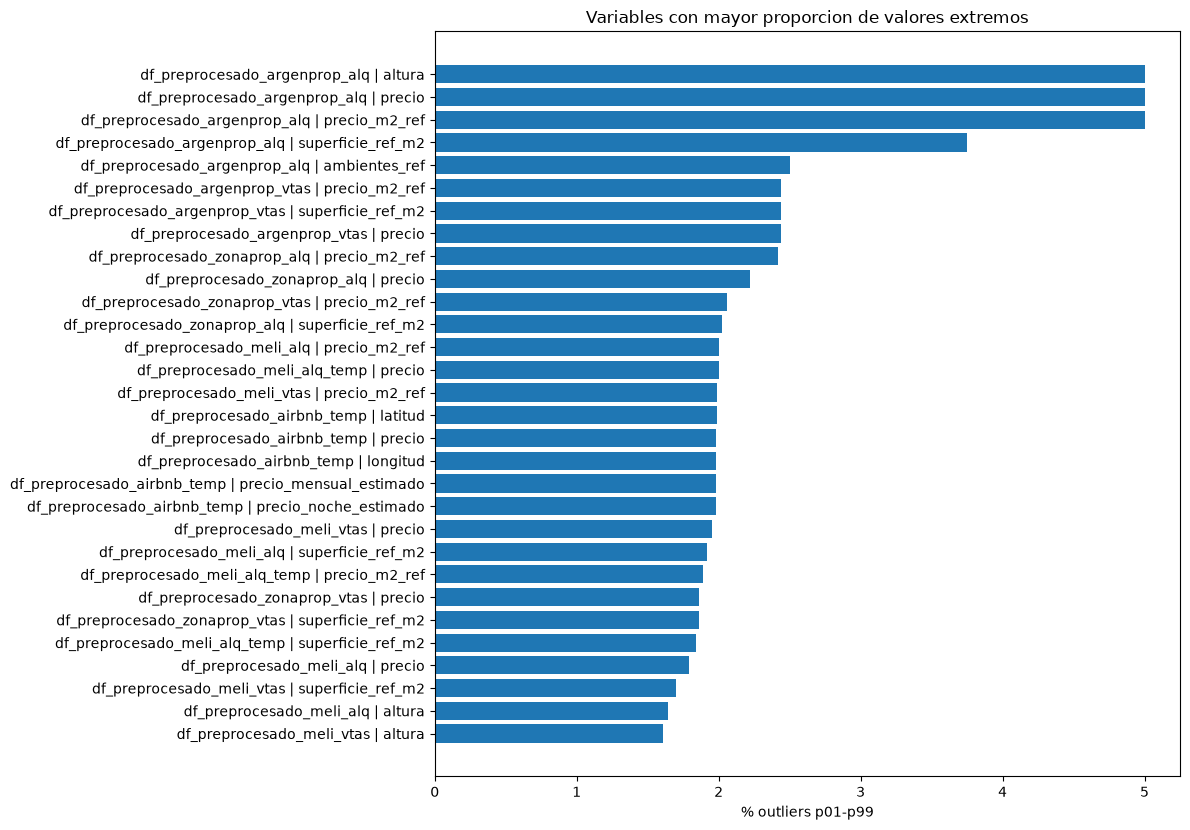

In [ ]:
try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    import matplotlib.pyplot as plt
    HAS_SEABORN = False

if not reporte_outliers.empty:
    pivot_outliers = reporte_outliers.pivot_table(index=['dataset', 'variable'], values='pct_outliers_p01_p99', aggfunc='mean').sort_values('pct_outliers_p01_p99', ascending=False)
    display(pivot_outliers.head(40))

    top_plot = pivot_outliers.head(30).reset_index()
    plt.figure(figsize=(12, max(5, len(top_plot) * 0.28)))
    labels = top_plot['dataset'] + ' | ' + top_plot['variable']
    plt.barh(labels, top_plot['pct_outliers_p01_p99'])
    plt.xlabel('% outliers p01-p99')
    plt.title('Variables con mayor proporcion de valores extremos')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Guardado de versiones con flags de outliers

In [ ]:
for name, df in preprocesados_con_outliers.items():
    path = PROCESSED_DIR / f'{name}_con_outliers_v1.csv'
    df.to_csv(path, index=False)
    print('Guardado:', path.relative_to(REPO_ROOT), df.shape)

canonical_cols = [
    'id_publicacion', 'fuente_norm', 'fuente', 'tipo_operacion_norm', 'tipo_operacion', 'url', 'fecha_extraccion',
    'scraped_at_utc', '_archivo_origen', 'titulo', 'descripcion', 'tipo_propiedad', 'moneda_norm', 'moneda',
    'precio', 'precio_texto', 'precio_m2_ref', 'precio_noche_estimado', 'precio_mensual_estimado', 'barrio',
    'barrio_norm', 'comuna', 'localidad', 'provincia', 'pais', 'direccion', 'direccion_completa', 'calle',
    'altura', 'latitud', 'longitud', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref', 'banios_ref'
]
frames = []
for name, df in preprocesados_con_outliers.items():
    cols = [c for c in df.columns if c in canonical_cols or c.endswith('_is_null') or c.endswith('_flag')]
    tmp = df[cols].copy()
    tmp['dataset_preprocesado'] = name
    frames.append(tmp)

df_publicaciones_consolidadas_outliers = pd.concat(frames, ignore_index=True, sort=False)
df_publicaciones_consolidadas_outliers.to_csv(PROCESSED_DIR / 'df_publicaciones_consolidadas_con_outliers_v1.csv', index=False)
print(df_publicaciones_consolidadas_outliers.shape)

Guardado: data\processed\df_preprocesado_meli_alq_con_outliers_v1.csv (11479, 117)
Guardado: data\processed\df_preprocesado_meli_alq_temp_con_outliers_v1.csv (6190, 118)
Guardado: data\processed\df_preprocesado_meli_vtas_con_outliers_v1.csv (44013, 119)
Guardado: data\processed\df_preprocesado_argenprop_vtas_con_outliers_v1.csv (82, 204)
Guardado: data\processed\df_preprocesado_argenprop_alq_con_outliers_v1.csv (80, 204)
Guardado: data\processed\df_preprocesado_zonaprop_vtas_con_outliers_v1.csv (485, 207)
Guardado: data\processed\df_preprocesado_zonaprop_alq_con_outliers_v1.csv (495, 207)
Guardado: data\processed\df_preprocesado_airbnb_temp_con_outliers_v1.csv (9596, 114)
(72420, 173)


## Criterio de cierre

No se eliminan automáticamente outliers plausibles. Los valores imposibles quedan identificados con flags y las variables extremas se marcan por percentiles dentro de fuente/operación/moneda cuando esas columnas existen.